<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

/content


'/content/drive/MyDrive/CDAC'

In [ ]:
from scipy.stats import binom, poisson, norm, t
binom.pmf(50,80,0.7)
binom.cdf(49,80,0.7)

np.float64(0.058748113591172955)

In [ ]:
poisson.pmf(5,7)
poisson.cdf(5,7)

np.float64(0.3007082761743609)

In [ ]:
# z-value
# z = (x-mean)/std
norm.cdf(1.73)

np.float64(0.9581848623864051)

### Student's t Distribution
1. Population standard deviation, sample standard deviation is known.
2. Necessarly used when the sample size is less than equal to 30.
3. normal sistribution doesn't work on such small size.

In [ ]:
z = (14-15.3)/1.8
t.cdf(z,14)

np.float64(0.2410240907076217)

In [ ]:
norm.cdf(z)

np.float64(0.23507893142883468)

### Exponenial Distribution

This exponenial Distribution is used to mode/predict time gap between time gap between two successive event.

MTBF - mean time between failure

unit - hour/case(incident)

rate of failure - 1/MTBF(incident/hr)

In [ ]:
from scipy.stats import expon

In [ ]:
expon.cdf(100,scale=43.8)

np.float64(0.898032895521957)

In [ ]:
# Question: you are living near station and you can hear horn 80 times a day
24/80 # geting distrub in 1 day
(24/80) * 60 # for distrub in 1 hour

18.0

In [ ]:
expon.cdf(1,scale=0.3)

np.float64(0.9643260066527476)

In [ ]:
# on an avg cp sir come 30 time in a 45 day course in 8 hour a day
print(8/30)
(8/30) * 45 # MTBF

0.26666666666666666


12.0

In [ ]:
expon.cdf(8,scale=12) # scale=MTBF

np.float64(0.486582880967408)

## Practice on Dataset

In [ ]:
df = pd.read_excel('data1.xlsx')
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [ ]:
df.isnull().sum()

,0
Category,80


In [ ]:
# Finding missing value
np.where(df.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [ ]:
# how many percent of missing value
80/df.shape[0]

0.16

In [ ]:
from collections import Counter
Counter(df.Category).most_common()

[('B', 113), ('A', 112), ('C', 101), ('D', 94), (nan, 80)]

Filling NA Values with MODE

In [ ]:
df.Category.fillna('B',inplace=True)
# OR
# df.Category = df.Category.fillna('B',inplace=True)
# df.Category.fillna(df.Category.mode()[0],inplace=True)

df.isnull().sum()

,0
Category,0


Filling NA values with Proportion

In [ ]:
df = pd.read_excel('data1.xlsx')
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [ ]:
df.Category.value_counts()

,count
Category,
B,113
A,112
C,101
D,94


In [ ]:
props = pd.DataFrame(df.Category.value_counts())

props.head()

,count
Category,
B,113
A,112
C,101
D,94


In [ ]:
props['Proportion'] = props['count']/sum(props['count'])
props.head()

,count,Proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


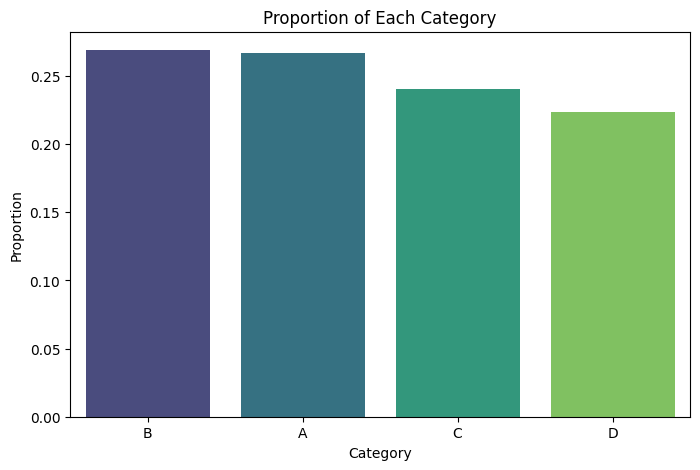

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=props.index, y='Proportion', data=props, palette='viridis', hue=props.index, legend=False)
plt.title('Proportion of Each Category')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.show()

In [ ]:
random_values = np.random.choice(['A','B','C','D'],size=80,p=props.Proportion)


In [ ]:
df.isnull().sum()

,0
Category,80


In [ ]:
ind = np.where (df.Category.isnull())

In [ ]:
df.loc[ind[0],'Category'] = random_values

In [ ]:
df.isnull().sum()

,0
Category,0


## Why we use Median rather than mean
- mean get change due to outlier
- if outlier is handled, then data might be skewed so mean will get affected due to that or data is asymetric
- if asymetric is handled, then mean is equal median in this case.

## How to handle Countinuous Data

Step 1: df.info()


In [ ]:
df = pd.read_excel('data2.xlsx')
df.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          850 non-null    object 
 1   Continuous_Value  880 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
df.Continuous_Value.isnull().sum()

np.int64(120)

In [ ]:
df1 = df.Continuous_Value.fillna(df.Continuous_Value.median())
df1.isnull().sum()

np.int64(0)

# Outlier

## Any values that are higher/Lower than UF/LF then they are Outlier.

## How to Interprete a Box Plot

[IQR](https://en.wikipedia.org/wiki/Interquartile_range)

IQR = Q3 - Q1

Upper fence(UF) = Q3 + 1.5xIQR

Lower fence(LF) = Q1 - 1.5xIQR

step1: Q1

step2: Q2

step 3: Q3

step 4: IQR

step 5: UF

step 6: LF

step 7: Highest Value between Q3 and UF

step 8: lowest value between Q1 and LF

- No values will be in (Highest Value between Q3 and UF) and UF

- No values will be in (Lowest Value between Q1 and LF) and LF

step 9 and 10 : UF/LF are calculated values they might be in the dataset but not exclusively there.


# Data3

# Data Visualization

In [61]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

### Bar Chart

Different bar's in the bar chart will not touch each other and would be equal thickness.


<BarContainer object of 5 artists>

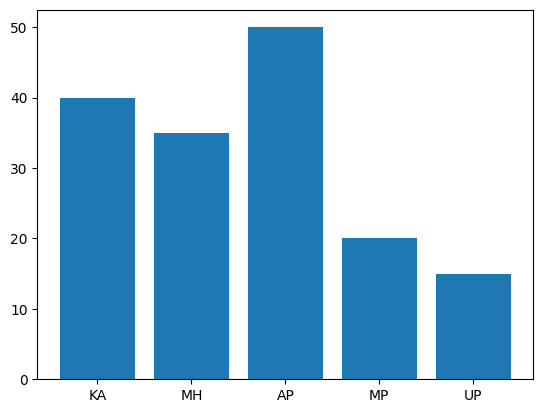

In [62]:
state = ['KA', 'MH', 'AP', 'MP', 'UP']
count = [40,35,50,20,15]

plt.bar(state,count)

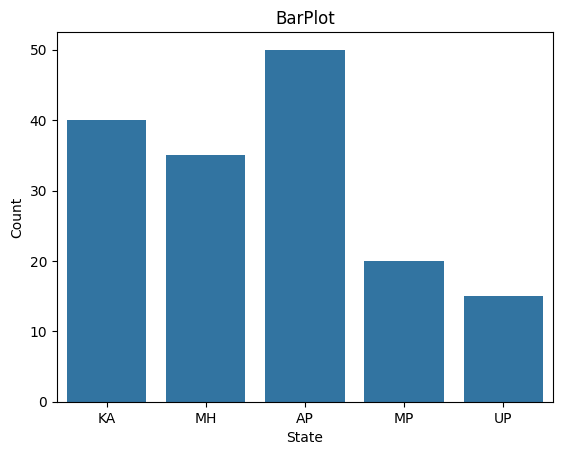

In [80]:
sns.barplot(x=state,y=count)

plt.title('BarPlot')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()

In [63]:
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [64]:
df1 = df.MaterialID.value_counts()
df1.head()

,count
MaterialID,
TMI-43T,15
AXCP-78,11
DDBN-89,8
SDRT-67,6
GCVB-79,5


<BarContainer object of 6 artists>

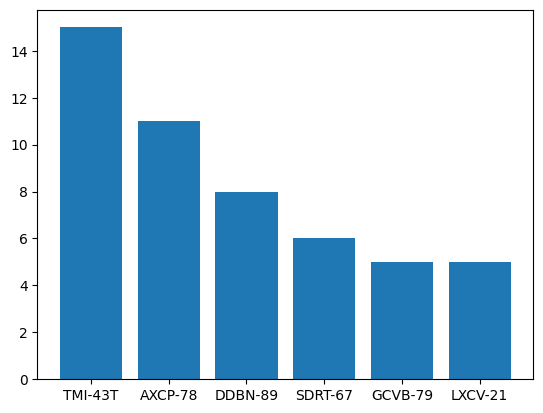

In [65]:
plt.bar(df1.index,df1)

In [70]:
df1 = df.MaterialID.value_counts().reset_index()
df1.head()
# Sorting data


,MaterialID,count
0,TMI-43T,15
1,AXCP-78,11
2,DDBN-89,8
3,SDRT-67,6
4,GCVB-79,5


In [74]:
df2 = df.groupby('MaterialID')
df2.groups

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}

In [77]:
df3 = df2.Quantity.agg('sum')
df3

,Quantity
MaterialID,
AXCP-78,898
DDBN-89,383
GCVB-79,182
LXCV-21,243
SDRT-67,294
TMI-43T,885


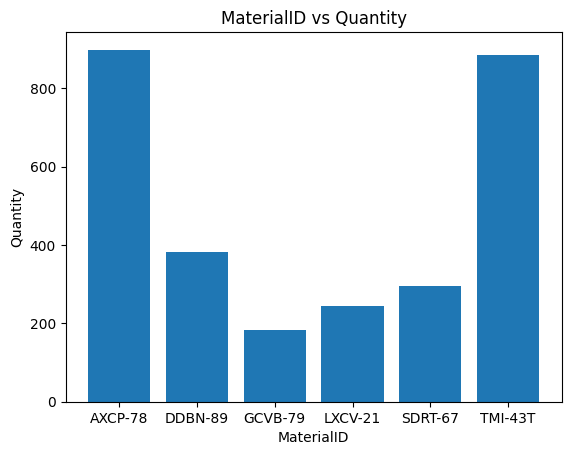

In [82]:
plt.bar(df3.index,df3)

plt.title('MaterialID vs Quantity')
plt.xlabel('MaterialID')
plt.ylabel('Quantity')
plt.show()

In [83]:
df1 = pd.crosstab(df.Location,df.MaterialID)
df1

MaterialID,AXCP-78,DDBN-89,GCVB-79,LXCV-21,SDRT-67,TMI-43T
Location,,,,,,
MWH-1,5,3,0,0,2,1
MWH-2,1,1,4,1,1,1
MWH-3,1,1,0,1,0,1
MWH-4,1,2,0,0,1,11
MWH-5,3,1,1,3,2,1


<Axes: xlabel='Location'>

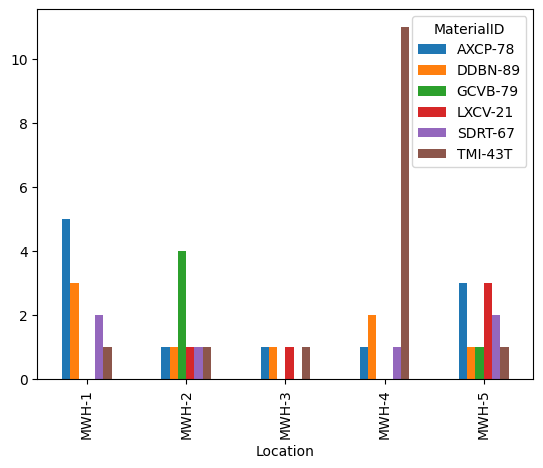

In [84]:
df1.plot(kind='bar')

### Effect of Categorical data to categorical data

In [85]:
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='nominal')
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2
